In [167]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt




In [168]:
df=pd.read_csv('customer_segmentation.csv')

In [169]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [170]:
df.shape

(2240, 29)

In [171]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [172]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [214]:
df["Customer_since"].describe()

count    2216.000000
mean     4718.521209
std       202.434667
min      4365.000000
25%      4545.000000
50%      4720.500000
75%      4894.000000
max      5064.000000
Name: Customer_since, dtype: float64

In [174]:
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()


ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [175]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   str           
 3   Marital_Status       2216 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[us]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   int64       

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [176]:
print(df["Education"].value_counts())
print(df["Marital_Status"].value_counts())

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64
Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [177]:
df["Total_children"]=df["Kidhome"]+df["Teenhome"]
df["Total_children"]

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_children, Length: 2216, dtype: int64

In [178]:
df["Age"]=2026-df["Year_Birth"]

df.columns

df["Age"]

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [179]:
df["Customer_since"]=(pd.Timestamp("today")-df["Dt_Customer"]).dt.days

In [180]:
spending_cols=['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
df["Total_Spending"]=df[spending_cols].sum(axis=1)

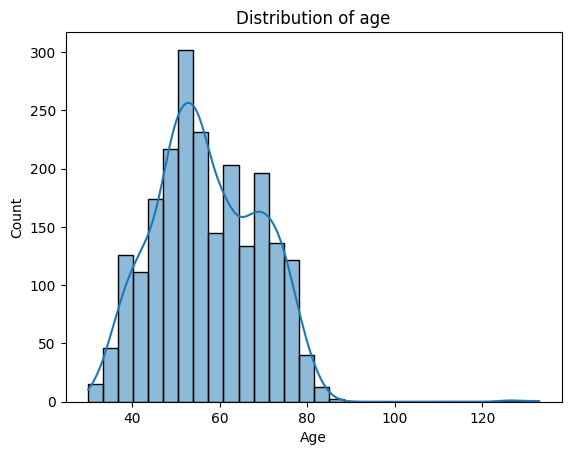

In [181]:
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("Distribution of age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


Text(0, 0.5, 'count')

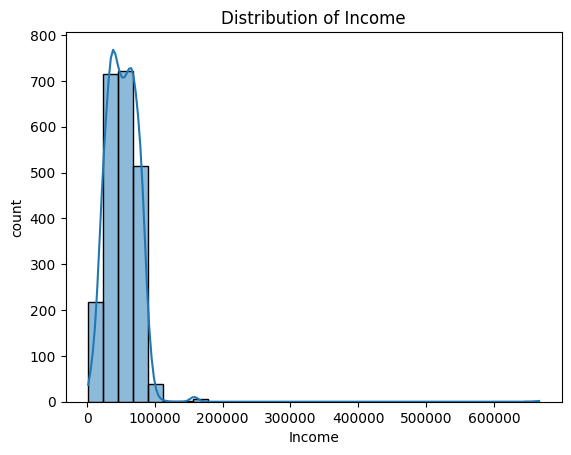

In [182]:
sns.histplot(df["Income"],bins=30,kde=True)
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("count")

Text(0, 0.5, 'count')

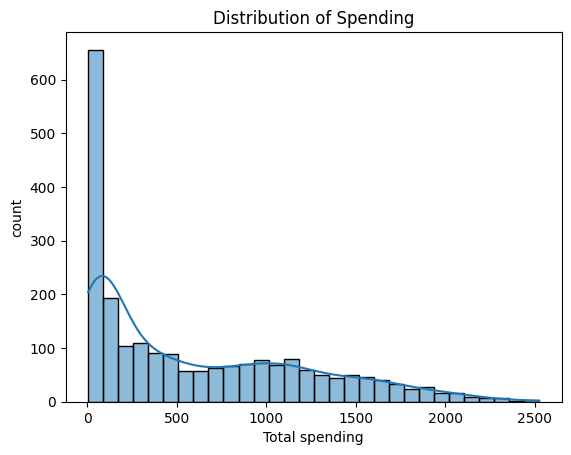

In [183]:
sns.histplot(df["Total_Spending"],bins=30,kde=True)
plt.title("Distribution of Spending")
plt.xlabel("Total spending")
plt.ylabel("count")

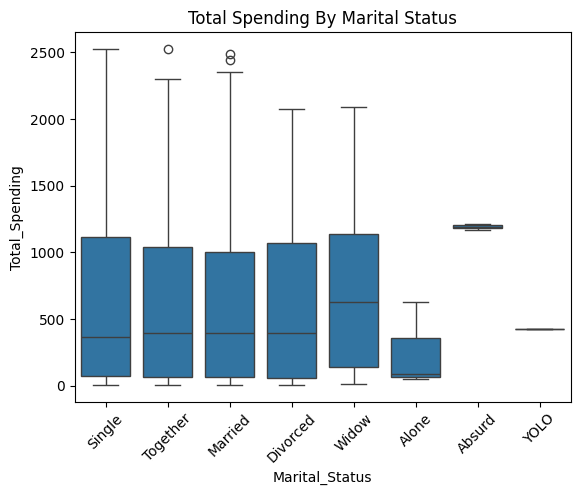

In [184]:
sns.boxplot(x="Marital_Status",y="Total_Spending",data=df)
plt.xticks(rotation=45)
plt.title("Total Spending By Marital Status")
plt.show()

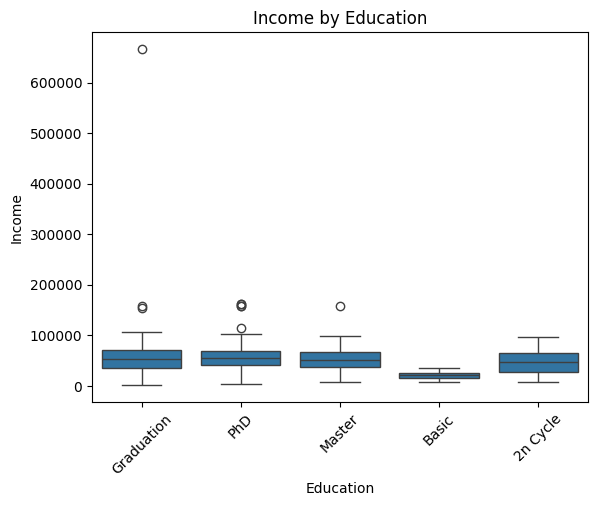

In [185]:
sns.boxplot(x="Education",y="Income",data=df)
plt.xticks(rotation=45)
plt.title("Income by Education")
plt.show()

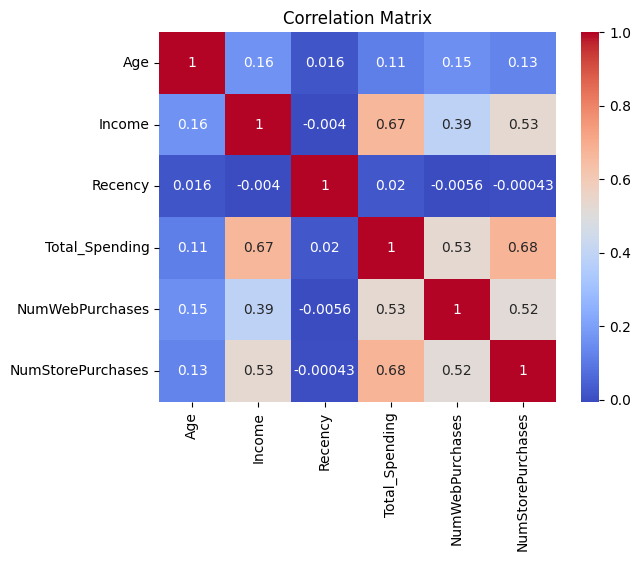

In [186]:
corr=df[["Age","Income","Recency","Total_Spending","NumWebPurchases","NumStorePurchases"]].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [187]:
pivot_income=df.pivot_table(values="Income",index="Education",columns="Marital_Status",aggfunc="mean")
pivot_income



Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


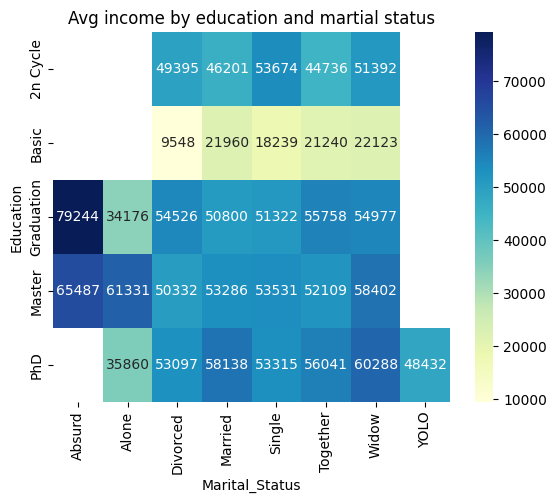

In [188]:
sns.heatmap(pivot_income,annot=True,fmt=".0f",cmap="YlGnBu")
plt.title("Avg income by education and martial status")
plt.show()

In [189]:
group1=df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

Text(0.5, 1.0, 'Mean Total Spending By Education')

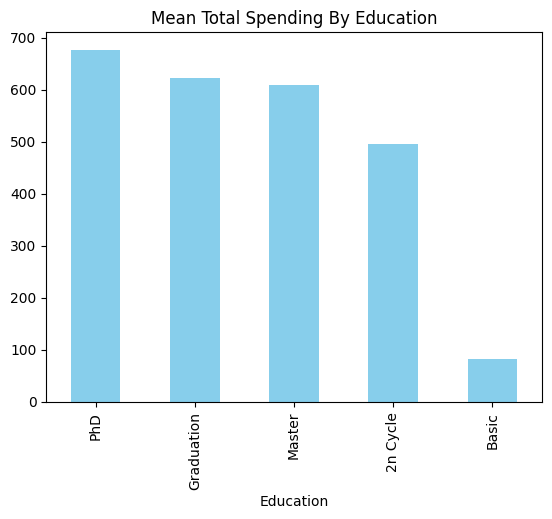

In [190]:
group1.plot(kind="bar",color="skyblue")
plt.title("Mean Total Spending By Education")


In [191]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Total_children', 'Age', 'Customer_since', 'Total_Spending'],
      dtype='str')

In [192]:
df["Acceptedany"]=df[['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2']].sum(axis=1)
df["Acceptedany"].unique()

array([0, 1, 2, 3, 4])

In [193]:
df["Acceptedany"]=df["Acceptedany"].apply(lambda x:1 if x>0 else 0)

In [194]:
df["Acceptedany"].unique()

array([0, 1])

In [195]:
group2=df.groupby("Marital_Status")["Acceptedany"].mean().sort_values(ascending=False)

Text(0.5, 1.0, 'Acceptancy of Campaign By Marital Status')

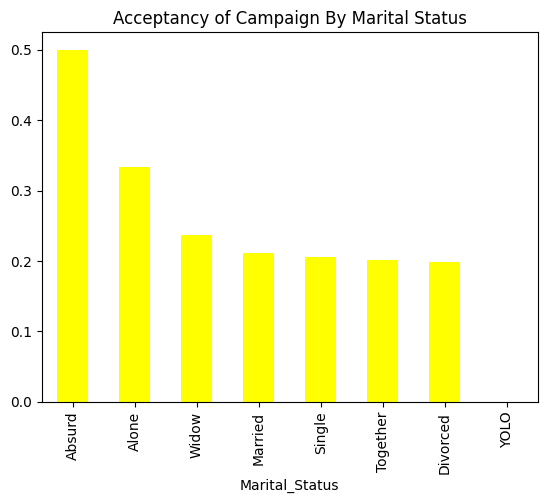

In [196]:
group2.plot(kind="bar",color="yellow")
plt.title("Acceptancy of Campaign By Marital Status")


In [197]:
bins=[18,30,40,50,60,70,90]
labels=["18-29","30-39","40-49","50-59","60-69","70+"]
df["Agegroup"]=pd.cut(df["Age"],bins=bins,labels=labels,right=False)


Text(0.5, 1.0, 'Mean Income by each age group')

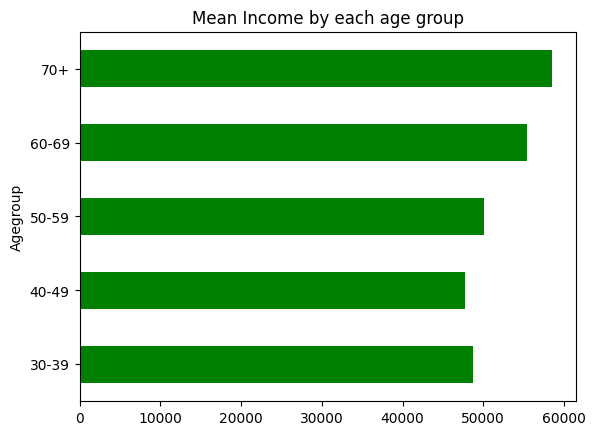

In [198]:
group3=df.groupby("Agegroup")["Income"].mean()
group3
group3.plot(kind="barh",color="green")
plt.title("Mean Income by each age group")

In [199]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Total_children', 'Age', 'Customer_since', 'Total_Spending',
       'Acceptedany', 'Agegroup'],
      dtype='str')

In [200]:
features=['Income','Age','Recency','NumWebVisitsMonth','Total_Spending','Customer_since','NumStorePurchases','NumWebPurchases']

In [201]:
X=df[features]
X

,Income,Age,Recency,NumWebVisitsMonth,Total_Spending,Customer_since,NumStorePurchases,NumWebPurchases
0,58138.0,69,58,7,1617,5028,4,8
1,46344.0,72,38,5,27,4478,2,1
2,71613.0,61,26,4,776,4677,10,8
3,26646.0,42,26,6,53,4504,4,2
4,58293.0,45,94,5,422,4526,6,5
...,...,...,...,...,...,...,...,...
2235,61223.0,59,46,5,1341,4746,4,9
2236,64014.0,80,56,7,444,4384,5,8
2237,56981.0,45,91,6,1241,4520,13,2
2238,69245.0,70,8,3,843,4521,10,6


In [202]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [203]:
X_Scaled=scaler.fit_transform(X)
from sklearn.cluster import KMeans
wcss=[]
for i in range(2,10):
    k_mean=KMeans(n_clusters=i)
    k_mean.fit(X_Scaled)
    wcss.append(k_mean.inertia_)



Text(0, 0.5, 'wcss')

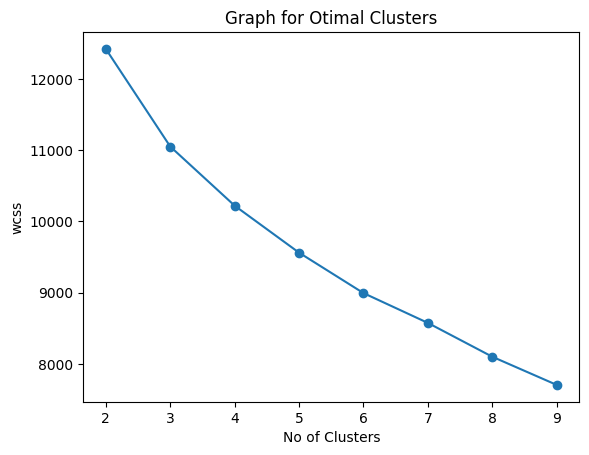

In [204]:
plt.plot(range(2,10),wcss,marker="o")
plt.title("Graph for Otimal Clusters")
plt.xlabel("No of Clusters")
plt.ylabel("wcss")

In [205]:
k_means=KMeans(n_clusters=6)
df["clusters"]=k_means.fit_predict(X_Scaled)
clustersummary=df.groupby("clusters")[features].mean()
clustersummary


,Income,Age,Recency,NumWebVisitsMonth,Total_Spending,Customer_since,NumStorePurchases,NumWebPurchases
clusters,,,,,,,,
0,38256.403846,56.788462,49.071154,5.482692,93.521154,4530.619231,3.373077,1.961538
1,29619.494824,50.975155,50.550725,7.523810,104.484472,4849.062112,3.004141,2.132505
2,75567.657627,46.294915,48.030508,2.738983,1324.647458,4707.877966,8.918644,4.861017
3,76774.527211,69.139456,52.476190,2.251701,1098.561224,4592.435374,7.523810,4.323129
4,66968.736059,62.814126,51.423792,5.565056,1237.323420,4905.066914,9.985130,6.996283
5,52680.571831,61.064789,42.954930,6.577465,562.236620,4788.059155,5.974648,6.805634


In [206]:
df["clusters"].value_counts()

clusters
0    520
1    483
5    355
2    295
3    294
4    269
Name: count, dtype: int64

In [207]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_Scaled)
pca_data
df["PCA1"],df["PCA2"]=pca_data[:,0],pca_data[:,1]

Text(0.5, 1.0, 'Customer Segmentation')

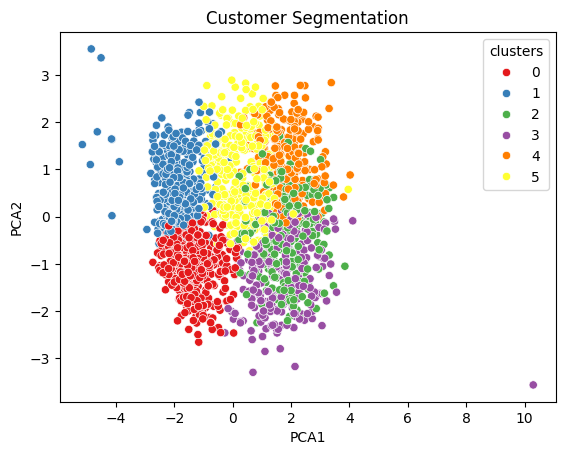

In [208]:
sns.scatterplot(x="PCA1",y="PCA2",hue="clusters",data=df,palette="Set1")
plt.title("Customer Segmentation")

In [209]:
import joblib
joblib.dump(k_means, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']